/tmp/ipykernel_430542/1337670390.py:236: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_430542/1337670390.py:236: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_430542/1337670390.py:236: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_430542/1337670390.py:236: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_430542/1337670390.py:236: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_430542/1337670390.py:236: UserWarning: Glyph 36830 (\N{CJK UNIFIED IDEOGRAPH-8FDE}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_430542/1337670390.py:236: UserWarning: Glyph 36890 (\N{CJK UNIFIED IDEOGRAPH-901A}) missing from curren

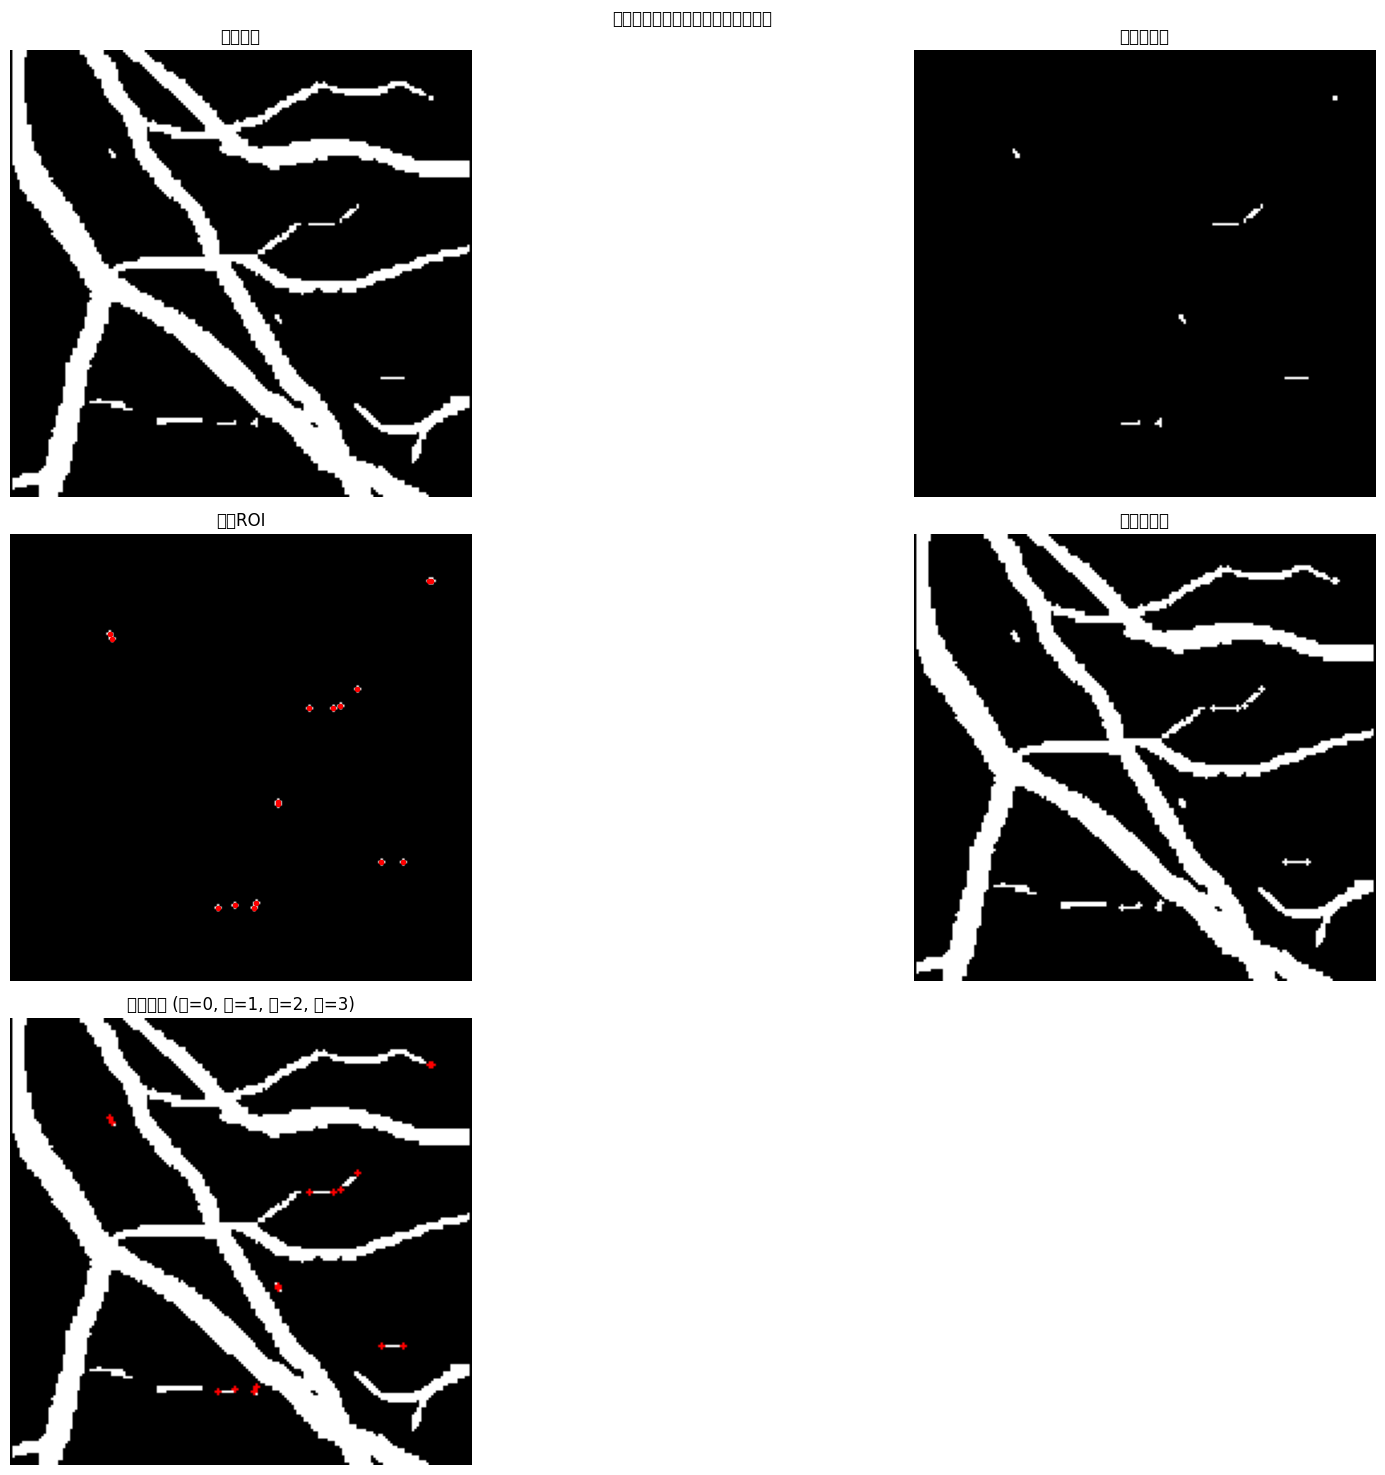

处理完成，结果已保存


In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from skimage.morphology import skeletonize
from scipy import ndimage

def get_small_components(binary_image, area_threshold):
    """
    获取面积小于阈值的连通分量
    
    参数:
    binary_image: 二值图像
    area_threshold: 面积阈值
    
    返回:
    labels: 标记图像
    stats: 连通分量统计信息
    small_components: 小连通分量的标签列表
    """
    # 标记连通分量
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        binary_image, connectivity=8
    )
    
    # 创建小连通分量掩码
    small_components_mask = np.zeros_like(binary_image)
    
    # 获取小连通分量的标签列表
    small_components = []
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area < area_threshold:
            small_components.append(i)
            small_components_mask[labels == i] = 255
    
    return labels, stats, centroids, small_components, small_components_mask

def find_endpoints(component_mask):
    """
    找到组件的端点
    
    参数:
    component_mask: 单个组件的二值掩码
    
    返回:
    endpoints: 端点坐标列表 [(y1,x1), (y2,x2), ...]
    """
    # 骨架化
    skeleton = skeletonize(component_mask / 255).astype(np.uint8)
    
    # 使用卷积找到端点
    kernel = np.array([
        [1, 1, 1],
        [1, 10, 1],
        [1, 1, 1]
    ])
    
    filtered = ndimage.convolve(skeleton, kernel, mode='constant', cval=0)
    
    # 端点的值是11（中心10 + 只有一个邻居值1）
    endpoints = np.where((filtered == 11) & (skeleton == 1))
    
    # 组合坐标
    return list(zip(endpoints[0], endpoints[1]))

def create_endpoint_roi_mask(binary_image, labels, small_components, endpoint_radius):
    """
    在小连通分量的端点周围创建感兴趣区域(ROI)
    
    参数:
    binary_image: 二值图像
    labels: 连通分量标签图
    small_components: 小连通分量的标签列表
    endpoint_radius: 端点周围ROI的半径
    
    返回:
    endpoint_roi_mask: 端点ROI掩码
    endpoints_coords: 所有端点的坐标
    """
    height, width = binary_image.shape
    endpoint_roi_mask = np.zeros_like(binary_image)
    all_endpoints = []
    
    # 为每个小连通分量找端点
    for label in small_components:
        # 创建当前组件的掩码
        component_mask = (labels == label).astype(np.uint8) * 255
        
        # 找到端点
        endpoints = find_endpoints(component_mask)
        all_endpoints.extend(endpoints)
        
        # 在每个端点周围创建圆形ROI
        for y, x in endpoints:
            y_min = max(0, y - endpoint_radius)
            y_max = min(height, y + endpoint_radius + 1)
            x_min = max(0, x - endpoint_radius)
            x_max = min(width, x + endpoint_radius + 1)
            
            # 使用圆形掩码
            for i in range(y_min, y_max):
                for j in range(x_min, x_max):
                    if ((i - y) ** 2 + (j - x) ** 2) <= endpoint_radius ** 2:
                        endpoint_roi_mask[i, j] = 255
    
    return endpoint_roi_mask, all_endpoints

def directional_dilation(binary_image, roi_mask=None):
    """
    对二值图像进行方向性膨胀处理。
    如果提供了ROI掩码，则只处理ROI区域内的像素。
    
    参数:
    binary_image: 二值图像(0和255)
    roi_mask: 感兴趣区域掩码，为None则处理整个图像
    
    返回:
    处理后的二值图像
    """
    # 创建输出图像
    result = binary_image.copy()
    height, width = binary_image.shape
    
    # 遍历每个像素（除了边界）
    for y in range(1, height - 1):
        for x in range(1, width - 1):
            # 如果有ROI掩码，则只处理ROI内的像素
            if roi_mask is not None and roi_mask[y, x] == 0:
                continue
                
            # 只处理值为0的像素
            if binary_image[y, x] == 0:
                # 检查四个方向
                # 方向1: 左上-右下
                if binary_image[y-1, x-1] == 255 or binary_image[y+1, x+1] == 255:
                    result[y, x] = 255
                # 方向2: 上-下
                elif binary_image[y-1, x] == 255 or binary_image[y+1, x] == 255:
                    result[y, x] = 255
                # 方向3: 右上-左下
                elif binary_image[y-1, x+1] == 255 or binary_image[y+1, x-1] == 255:
                    result[y, x] = 255
                # 方向4: 左-右
                elif binary_image[y, x-1] == 255 or binary_image[y, x+1] == 255:
                    result[y, x] = 255
    
    return result

def create_multi_value_image(binary_image, roi_mask):
    """
    创建一个包含多个值的图像:
    0: 背景
    1: 原始前景
    2: ROI区域
    3: 可用于后续修改的值
    
    参数:
    binary_image: 二值图像(0和255)
    roi_mask: ROI区域掩码(0和255)
    
    返回:
    包含多个值的图像
    """
    # 创建基本图像，将255转换为1
    multi_value_img = (binary_image > 0).astype(np.uint8)
    
    # 在ROI区域设置值为2
    roi_area = (roi_mask > 0).astype(np.uint8)
    multi_value_img[roi_area == 1] = 2
    
    # 值3留空，将用于后续修改
    
    return multi_value_img

def visualize_multi_value(multi_value_img):
    """
    可视化多值图像
    """
    # 创建可视化图像
    vis_img = np.zeros((*multi_value_img.shape, 3), dtype=np.uint8)
    
    # 设置各值的颜色
    # 0: 黑色 (背景，已经是黑色)
    # 1: 白色 (原始前景)
    vis_img[multi_value_img == 1] = [255, 255, 255]
    # 2: 红色 (ROI区域)
    vis_img[multi_value_img == 2] = [255, 0, 0]
    # 3: 绿色 (可修改区域)
    vis_img[multi_value_img == 3] = [0, 255, 0]
    
    return vis_img

def visualize_results(original, small_components_mask, endpoint_roi_mask, processed, multi_value_img, endpoints=None):
    """
    可视化原始图像、小连通分量、端点ROI、处理后的图像和多值图像
    """
    fig = plt.figure(figsize=(20, 15))
    gs = GridSpec(3, 2, figure=fig)
    
    # 显示原始图像
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(original, cmap='gray')
    ax1.set_title("原始图像")
    ax1.axis('off')
    
    # 显示小连通分量
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.imshow(small_components_mask, cmap='gray')
    ax2.set_title("小连通分量")
    ax2.axis('off')
    
    # 显示端点ROI
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.imshow(endpoint_roi_mask, cmap='gray')
    if endpoints:
        for y, x in endpoints:
            ax3.plot(x, y, 'ro', markersize=3)
    ax3.set_title("端点ROI")
    ax3.axis('off')
    
    # 显示处理后图像
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.imshow(processed, cmap='gray')
    ax4.set_title("处理后图像")
    ax4.axis('off')
    
    # 显示多值图像
    ax5 = fig.add_subplot(gs[2, 0])
    multi_value_vis = visualize_multi_value(multi_value_img)
    ax5.imshow(multi_value_vis)
    ax5.set_title("多值图像 (黑=0, 白=1, 红=2, 绿=3)")
    ax5.axis('off')
    
    plt.suptitle("基于连通分量端点的方向性膨胀处理")
    plt.tight_layout()
    plt.show()

def main(no):
    # 加载图像
    image_path = "/home/xkw/pxlames/segmentation/论文图/2/2-图片 3.png"  # 请替换为你的图像路径
    
    try:
        # 读取图像
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        
        if img is None:
            print(f"无法读取图像 {image_path}")
            return
        
        # 确保图像是二值图像
        _, binary_img = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
        
        # 设置连通分量面积阈值
        area_threshold = 20  # 可以根据实际情况调整
        
        # 获取小连通分量
        labels, stats, centroids, small_components, small_components_mask = get_small_components(binary_img, area_threshold)
        
        # 设置端点周围ROI的半径
        endpoint_radius = 1  # 可以根据实际情况调整
        
        # 创建端点ROI掩码
        endpoint_roi_mask, endpoints = create_endpoint_roi_mask(binary_img, labels, small_components, endpoint_radius)
        
        # 进行方向性膨胀处理，只处理端点ROI区域
        processed_img = directional_dilation(binary_img, endpoint_roi_mask)
        
        # 创建多值图像，其中ROI区域标记为2
        multi_value_img = create_multi_value_image(binary_img, endpoint_roi_mask)
        
        # 显示结果
        visualize_results(binary_img, small_components_mask, endpoint_roi_mask, processed_img, multi_value_img, endpoints)
        
        # 保存结果
        # cv2.imwrite("small_components_mask.png", small_components_mask)
        # cv2.imwrite("endpoint_roi_mask.png", endpoint_roi_mask)
        # cv2.imwrite("directional_dilation_result.png", processed_img)
        np.savetxt(no+"-multi_value_image.txt", multi_value_img, fmt='%d')  # 保存为整数格式
        print("处理完成，结果已保存")
        
    except Exception as e:
        print(f"处理图像时发生错误: {str(e)}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main("3")

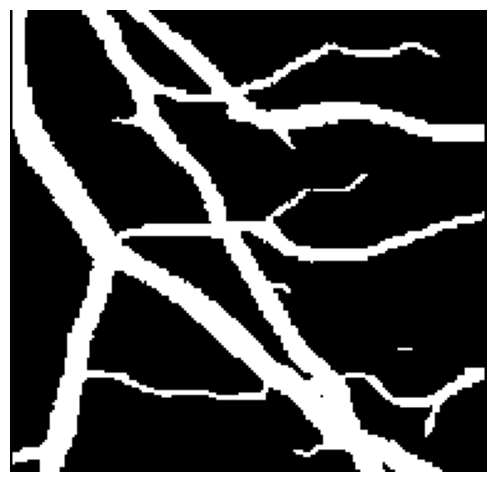

In [17]:
import numpy as np
import matplotlib.pyplot as plt

no = "3"
# 读取.txt文件
try:
    with open('/home/xkw/pxlames/segmentation/论文图/2/2-3.txt', 'r') as file:
        lines = file.readlines()
    
    # 过滤空行并转换为数值
    data = []
    for line in lines:
        line = line.strip()
        if line:  # 跳过空行
            row = [int(val) for val in line.split()]
            if row:  # 确保行不为空
                data.append(row)
    
    # 转换为numpy数组
    data = np.array(data)
    
    # 检查数据是否为空
    if data.size == 0:
        raise ValueError("No valid data found in the file")
    
    # 根据要求调整像素值
    data[data == 2] = 0
    
    # 使用plt显示图像
    plt.figure(figsize=(8, 6))
    plt.imshow(data, cmap='gray')
    # plt.title('Image from Text Data')
    plt.axis('off')
    plt.savefig(no+'-output_image.png')  # 保存图像到当前文件夹
    plt.show()
    
except FileNotFoundError:
    print("Error: File not found. Please check the file path.")
except ValueError as e:
    print(f"Error processing data: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

/tmp/ipykernel_441775/1624528265.py:65: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_441775/1624528265.py:65: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_441775/1624528265.py:65: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_441775/1624528265.py:65: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_441775/1624528265.py:65: UserWarning: Glyph 33192 (\N{CJK UNIFIED IDEOGRAPH-81A8}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_441775/1624528265.py:65: UserWarning: Glyph 32960 (\N{CJK UNIFIED IDEOGRAPH-80C0}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_441775/1624528265.py:65: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from current font.

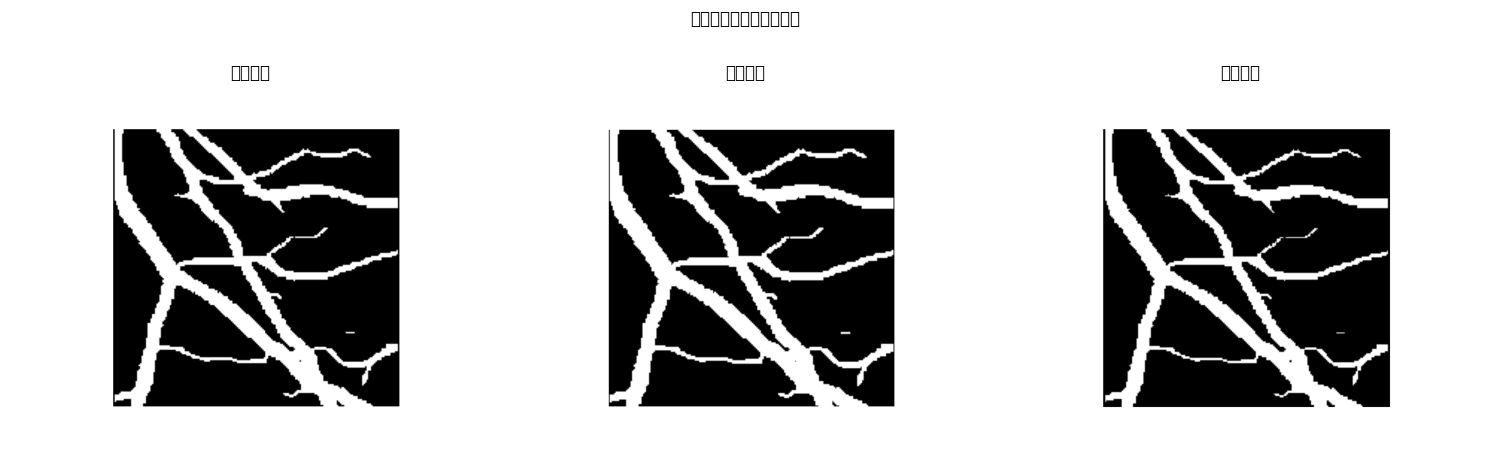

处理完成，结果已保存为original.png、dilated.png和eroded.png


In [18]:
# closing：
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

def process_image(image_path, kernel_size=5):
    """
    读取图像并进行膨胀和腐蚀操作
    
    参数:
    image_path: 图像文件路径
    kernel_size: 结构元素的大小
    
    返回:
    原图、膨胀结果、腐蚀结果
    """
    # 读取图像
    image = cv2.imread(image_path)
    
    # 如果是彩色图像，转换为灰度图
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image
    
    # 创建结构元素
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    
    eroded = cv2.erode(gray, kernel, iterations=1)
    
    # 膨胀操作
    dilated = cv2.dilate(gray, kernel, iterations=1)
    
    # 腐蚀操作
    
    return gray, dilated, eroded

def visualize_results(original, dilated, eroded, title="图像膨胀与腐蚀处理结果"):
    """
    可视化原始图像、膨胀结果和腐蚀结果
    """
    fig = plt.figure(figsize=(15, 5))
    gs = GridSpec(1, 3, figure=fig)
    
    # 显示原始图像
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(original, cmap='gray')
    ax1.set_title("原始图像")
    ax1.axis('off')
    
    # 显示膨胀结果
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.imshow(dilated, cmap='gray')
    ax2.set_title("膨胀结果")
    ax2.axis('off')
    
    # 显示腐蚀结果
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.imshow(eroded, cmap='gray')
    ax3.set_title("腐蚀结果")
    ax3.axis('off')
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def main(no):
    # 图像路径
    image_path = "/home/xkw/pxlames/segmentation/论文图/3-output_image.png"  # 替换为你的图像路径
    
    # 结构元素大小
    kernel_size = 2  # 可以调整这个值
    
    # 处理图像
    original, dilated, eroded = process_image(image_path, kernel_size)
    
    # 显示结果
    visualize_results(original, dilated, eroded)
    
    # 保存结果
    # cv2.imwrite("original.png", original)
    cv2.imwrite(no+"-dilated_final.png", dilated)
    # cv2.imwrite("eroded.png", eroded)
    
    print("处理完成，结果已保存为original.png、dilated.png和eroded.png")

if __name__ == "__main__":
    main("3")